In [14]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import xarray as xr
import proplot as pplt
warnings.filterwarnings('ignore')
pplt.rc.update({
    'savefig.dpi':900,
    'savefig.bbox':'tight',
    'savefig.pad_inches':0.02,
    'tick.minor':False,
    'font.size':9,
    'label.size':9,
    'tick.labelsize':9,
    'title.size':9,
    'abc.size':9,
    'legend.fontsize':9,
    'suptitle.size':9,
    'leftlabelsize':9,
    'toplabelsize':9,
    'leftlabel.weight':'normal',
    'toplabel.weight':'normal',
    'reso':'xx-hi'})

In [15]:
with open('../scripts/configs.json','r',encoding='utf-8') as f:
    CONFIGS = json.load(f)
SPLITSDIR  = CONFIGS['filepaths']['splits']
WEIGHTSDIR = CONFIGS['filepaths']['weights']
MODELSDIR  = CONFIGS['filepaths']['models']
PREDSDIR   = CONFIGS['filepaths']['predictions']
FIELDVARS  = CONFIGS['experiments']['nn']['runs']['nn_gauss']['fieldvars']
SEEDS      = CONFIGS['experiments']['nn']['seeds']
LATRANGE   = CONFIGS['domain']['latrange']
LONRANGE   = CONFIGS['domain']['lonrange']
SPLIT      = 'test'
NBINS      = 20
MINSAMPLES = 50
MINPRECIP  = 0.1
LFCLASSES  = {'Ocean':((0.0,0.1),'#539ED4'),'Coast':((0.1,0.9),'gray6'),'Land':((0.9,1.01),'#A0522D')}
REGISTRY   = {row['name']:dict(form=row['form'],constants=json.loads(row['constants']),train_loss=row['train_loss'],valid_loss=row['valid_loss'])
              for _,row in pd.read_csv(os.path.join(MODELSDIR,'sr','optimized_equations.csv')).iterrows()}

In [16]:
def kernel_integrate(fields,weights,dsig):
    return (fields*weights[None,:,:]*dsig[None,None,:]).sum(axis=2)

def calc_dominant_term(rh,thetae,thetaestar):
    return np.maximum(kappa*(rh-rh0),thetae-gamma*thetaestar-thetac)

def calc_sensible_term(lf,shf):
    return lamshf*(lfc-lf)*(shf-shf0)

def calc_latent_term(lhf):
    return lamlhf*(lhf-lhf0)

def to_precip(exponent):
    return np.maximum(np.expm1(exponent),0.0)

def bin_1d(x,z,edges,minsamples=MINSAMPLES):
    xi     = np.clip(np.digitize(x,edges)-1,0,len(edges)-2)
    counts = np.bincount(xi,minlength=len(edges)-1)
    sums   = np.bincount(xi,weights=z,minlength=len(edges)-1)
    return 0.5*(edges[:-1]+edges[1:]),np.where(counts>=minsamples,sums/np.maximum(counts,1),np.nan)

def calc_slope(x,y,minsamples=MINSAMPLES):
    if x.size<minsamples:
        return np.nan
    xanom = x-x.mean()
    return np.dot(xanom,y-y.mean())/np.dot(xanom,xanom)

In [17]:
with open(os.path.join(SPLITSDIR,'stats.json'),'r',encoding='utf-8') as f:
    STATS = json.load(f)
c3,c4,c5 = (REGISTRY['sr_atm_eq']['constants'][name] for name in ['c3','c4','c5'])
c6,c7,c8 = (REGISTRY['sr_sfc_eq']['constants'][name] for name in ['c6','c7','c8'])

eta    = STATS['tp_std']*c3/STATS['thetae_std']**3
gamma  = c4*STATS['thetae_std']/STATS['thetaestar_std']
thetac = STATS['thetae_mean']-gamma*STATS['thetaestar_mean']+c5*STATS['thetae_std']
kappa  = STATS['thetae_std']/STATS['rh_std']
rh0    = STATS['rh_mean']

lamshf = STATS['tp_std']*c6/STATS['shf_std']
lfc    = c7
shf0   = STATS['shf_mean']
lamlhf = STATS['tp_std']*c8/STATS['lhf_std']
lhf0   = STATS['lhf_mean']

constdf = pd.DataFrame([
    {'Constant':'$\\lambda_\mathrm{S}$','Value':f'{lamshf:.3e}','Units':'m²/W'},
    {'Constant':'$\\mathrm{LF}_c$','Value':f'{lf0:.2f}','Units':'dimensionless'},
    {'Constant':'$\\mathrm{SHF}_0$','Value':f'{shf0:.2f}','Units':'W/m²'},
    {'Constant':'$\\lambda_\mathrm{L}$','Value':f'{lamlhf:.3e}','Units':'m²/W'},
    {'Constant':'$\\mathrm{LHF}_0$','Value':f'{lhf0:.2f}','Units':'W/m²'}])
display(constdf.style.hide(axis='index'))

Constant,Value,Units
$\lambda_\mathrm{S}$,1.250e-02,m²/W
$\mathrm{LF}_c$,0.74,dimensionless
$\mathrm{SHF}_0$,13.91,W/m²
$\lambda_\mathrm{L}$,1.564e-03,m²/W
$\mathrm{LHF}_0$,124.39,W/m²


In [18]:
with xr.open_dataset(os.path.join(SPLITSDIR,f'{SPLIT}.h5'),engine='h5netcdf') as ds:
    ntime,nlat,nlon = (ds.sizes[dim] for dim in ['time','lat','lon'])
    lat,lon,dsig    = ds['lat'].values,ds['lon'].values,ds['dsig'].values
    fields = np.stack([ds[name].transpose('time','lat','lon','sig').values.reshape(-1,dsig.size) for name in FIELDVARS],axis=1)
    tp,shf,lhf = (ds[name].transpose('time','lat','lon').values.ravel() for name in ['tp','shf','lhf'])
    lf     = xr.broadcast(ds['lf'],ds['tp'])[0].transpose('time','lat','lon').values.ravel()
with xr.open_dataset(os.path.join(PREDSDIR,f'sr_sfc_eq_{SPLIT}_predictions.nc')) as ds:
    savedtp = ds['tp'].squeeze().transpose('time','lat','lon').values.ravel()

kernels = []
for seed in SEEDS:
    with xr.open_dataset(os.path.join(WEIGHTSDIR,f'nn_gauss_{seed}_weights.nc'),engine='h5netcdf') as ds:
        kernels.append(ds['k'].values)
integrals    = dict(zip(FIELDVARS,kernel_integrate(fields,np.mean(kernels,axis=0),dsig).T))
dominant     = calc_dominant_term(integrals['rh'],integrals['thetae'],integrals['thetaestar'])
sensibleterm = calc_sensible_term(lf,shf)
latentterm   = calc_latent_term(lhf)
surfaceterm  = sensibleterm+latentterm
atmtp        = to_precip(eta*dominant**3)
sfctp        = to_precip(eta*dominant**3+surfaceterm)
finite       = np.isfinite(dominant)&np.isfinite(surfaceterm)&np.isfinite(tp)
favorable    = finite&(atmtp>=MINPRECIP)
missed       = tp-atmtp
added        = sfctp-atmtp
print(f'Max difference from saved SR-SFC predictions: {np.nanmax(np.abs(sfctp[finite]-savedtp[finite])):.2e} mm')

lfmasks = {name:(lf>=bounds[0])&(lf<bounds[1]) for name,(bounds,_) in LFCLASSES.items()}
colors  = {name:color for name,(_,color) in LFCLASSES.items()}

Max difference from saved SR-SFC predictions: 8.94e-02 mm


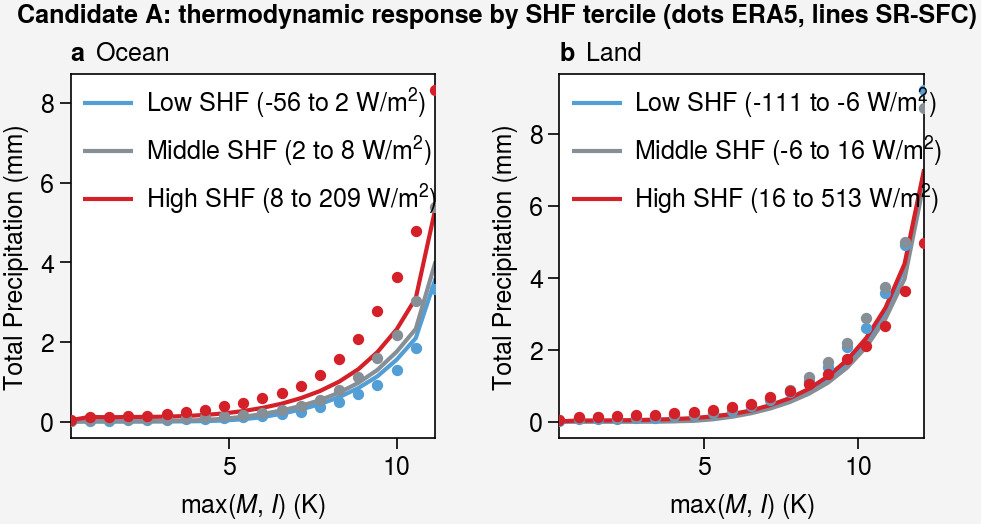

In [19]:
regionmasks = {'Ocean':finite&(lf<0.5),'Land':finite&(lf>=0.5)}
tercolors   = {'Low SHF':'#539ED4','Middle SHF':'gray6','High SHF':'#D42028'}

fig,axs = pplt.subplots(ncols=2,figwidth=5,share=False)
for ax,(region,regionmask) in zip(axs,regionmasks.items()):
    edges  = np.linspace(0,np.percentile(dominant[regionmask],99.5),NBINS+1)
    bounds = np.percentile(shf[regionmask],[0,100/3,200/3,100])
    for (label,color),lo,hi in zip(tercolors.items(),bounds[:-1],bounds[1:]):
        mask = regionmask&(shf>=lo)&(shf<=hi)
        centers,era5mean = bin_1d(dominant[mask],tp[mask],edges)
        _,sfcmean        = bin_1d(dominant[mask],sfctp[mask],edges)
        ax.scatter(centers,era5mean,color=color,s=12,zorder=3)
        ax.plot(centers,sfcmean,color=color,lw=1.5,label=f'{label} ({lo:.0f} to {hi:.0f} W/m$^2$)')
    ax.format(title=region,xlabel='max($\\mathit{M}$, $\\mathit{I}$) (K)',ylabel='Total Precipitation (mm)')
    ax.legend(loc='ul',ncols=1,frame=False)
fig.format(abc=True,titleloc='l',grid=False,suptitle='Candidate A: thermodynamic response by SHF tercile (dots ERA5, lines SR-SFC)')
pplt.show()

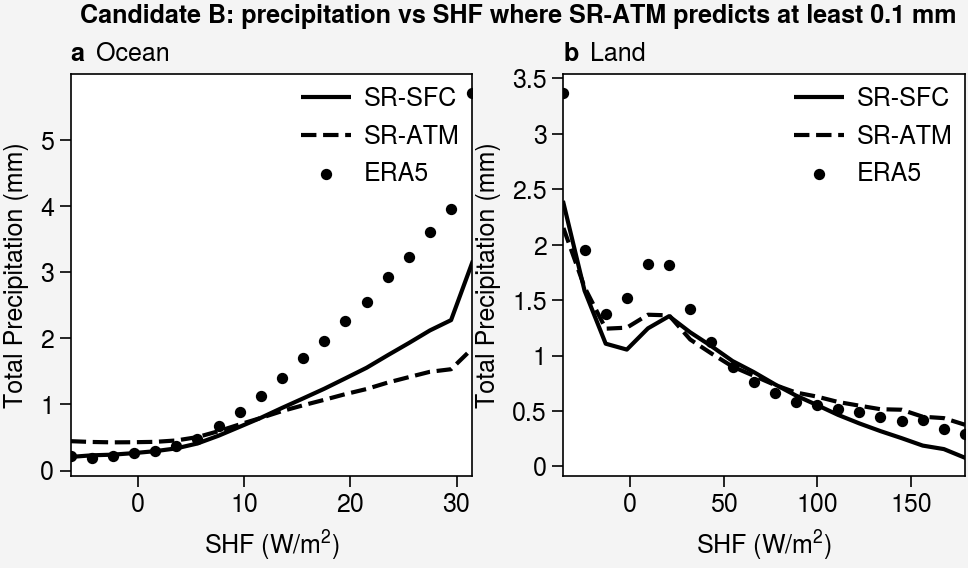

In [20]:
fig,axs = pplt.subplots(ncols=2,figwidth=5,share=False)
for ax,(region,regionmask) in zip(axs,[('Ocean',favorable&(lf<0.5)),('Land',favorable&(lf>=0.5))]):
    edges = np.linspace(*np.percentile(shf[regionmask],[1,99]),NBINS+1)
    for values,label,style in [(tp,'ERA5',None),(sfctp,'SR-SFC','-'),(atmtp,'SR-ATM','--')]:
        centers,means = bin_1d(shf[regionmask],values[regionmask],edges)
        if style is None:
            ax.scatter(centers,means,color='k',s=12,label=label,zorder=3)
        else:
            ax.plot(centers,means,color='k',lw=1.5,ls=style,label=label)
    ax.format(title=region,xlabel='SHF (W/m$^2$)',ylabel='Total Precipitation (mm)')
    ax.legend(loc='ur',ncols=1,frame=False)
fig.format(abc=True,titleloc='l',grid=False,suptitle=f'Candidate B: precipitation vs SHF where SR-ATM predicts at least {MINPRECIP} mm')
pplt.show()

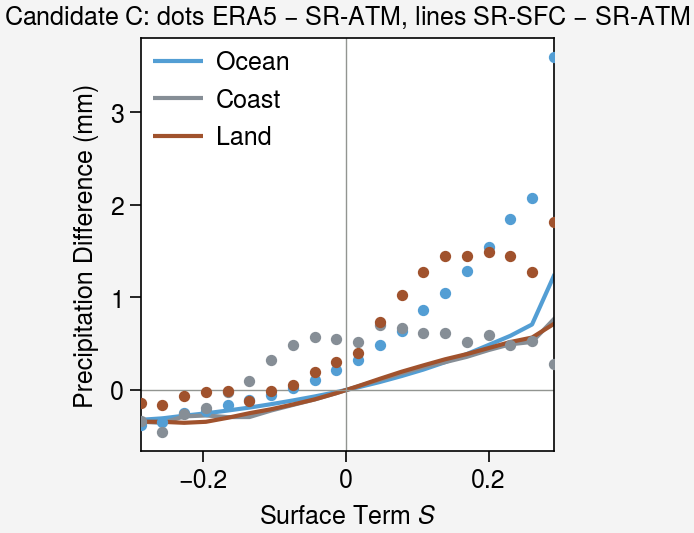

In [21]:
edges = np.linspace(*np.percentile(surfaceterm[favorable],[1,99]),NBINS+1)

fig,ax = pplt.subplots(figwidth=3.2)
for name,lfmask in lfmasks.items():
    mask = favorable&lfmask
    centers,missmean = bin_1d(surfaceterm[mask],missed[mask],edges)
    _,addmean        = bin_1d(surfaceterm[mask],added[mask],edges)
    ax.scatter(centers,missmean,color=colors[name],s=12,zorder=3)
    ax.plot(centers,addmean,color=colors[name],lw=1.5,label=name)
ax.axhline(0,color='gray',lw=0.5)
ax.axvline(0,color='gray',lw=0.5)
ax.format(xlabel='Surface Term $\\mathit{S}$',ylabel='Precipitation Difference (mm)',grid=False,
          title='Candidate C: dots ERA5 $-$ SR-ATM, lines SR-SFC $-$ SR-ATM')
ax.legend(loc='ul',ncols=1,frame=False)
pplt.show()

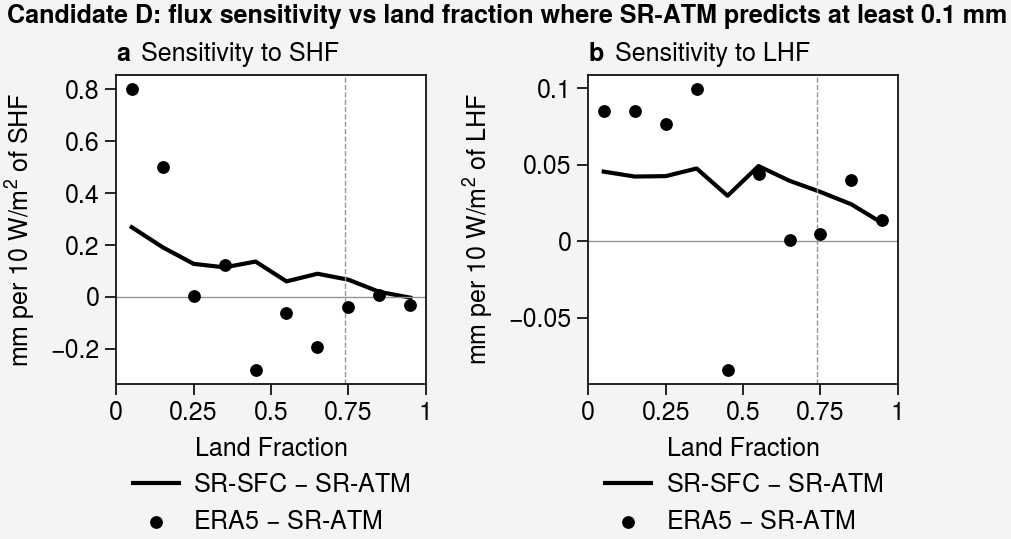

In [24]:
lfedges   = np.linspace(0,1,11)
lfcenters = 0.5*(lfedges[:-1]+lfedges[1:])
lfindex   = np.clip(np.digitize(lf,lfedges)-1,0,len(lfcenters)-1)

fig,axs = pplt.subplots(ncols=2,figwidth=5,share=False)
for ax,(flux,label) in zip(axs,[(shf,'SHF'),(lhf,'LHF')]):
    for values,name,style in [(missed,'ERA5 $-$ SR-ATM',None),(added,'SR-SFC $-$ SR-ATM','-')]:
        slopes = [10*calc_slope(flux[favorable&(lfindex==i)],values[favorable&(lfindex==i)]) for i in range(len(lfcenters))]
        if style is None:
            ax.scatter(lfcenters,slopes,color='k',s=16,label=name,zorder=3)
        else:
            ax.plot(lfcenters,slopes,color='k',lw=1.5,label=name)
    ax.axhline(0,color='gray',lw=0.5)
    ax.axvline(lfc,color='gray',lw=0.5,ls='--')
    ax.format(title=f'Sensitivity to {label}',xlabel='Land Fraction',ylabel=f'mm per 10 W/m$^2$ of {label}',xlim=(0,1))
    ax.legend(loc='b',ncols=1,frame=False)
fig.format(abc=True,titleloc='l',grid=False,suptitle=f'Candidate D: flux sensitivity vs land fraction where SR-ATM predicts at least {MINPRECIP} mm')
pplt.show()

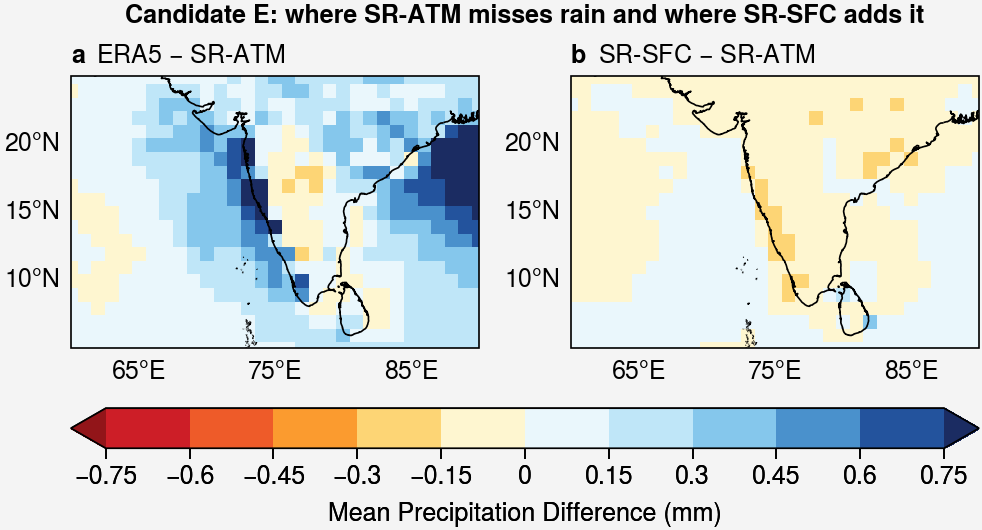

In [23]:
missmap = np.nanmean(np.where(finite,missed,np.nan).reshape(ntime,nlat,nlon),axis=0)
addmap  = np.nanmean(np.where(finite,added,np.nan).reshape(ntime,nlat,nlon),axis=0)
maplim  = np.nanpercentile(np.abs([missmap,addmap]),98)
kwmap   = dict(coast=True,lonlim=LONRANGE,lonlines=[65,75,85],lonlabels='b',
               latlim=LATRANGE,latlines=[10,15,20],latlabels='l',grid=False)

fig,axs = pplt.subplots(ncols=2,figwidth=5,proj='cyl')
for ax,values,title in zip(axs,[missmap,addmap],['ERA5 $-$ SR-ATM','SR-SFC $-$ SR-ATM']):
    mmap = ax.pcolormesh(lon,lat,values,cmap='ColdHot_r',vmin=-maplim,vmax=maplim,extend='both')
    ax.format(title=title,**kwmap)
fig.colorbar(mmap,loc='b',label='Mean Precipitation Difference (mm)')
fig.format(abc=True,titleloc='l',suptitle='Candidate E: where SR-ATM misses rain and where SR-SFC adds it')
pplt.show()